# Analysis of Repeated Antibiotics

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
import os
import glob
import gzip
from matplotlib.ticker import PercentFormatter
import logging, sys
%matplotlib inline

In [4]:
current_working_dir = os.getcwd()
print(current_working_dir)

c:\Users\m84300af\OneDrive - The University of Manchester\Documents\GitHub\amr-uom-brit


In [52]:
data = pd.read_csv(r'../output/measures/input_2019-01-01.csv.gz', compression='gzip')
#data = pd.read_csv(r'../output/measures/input_all.csv')
data.head()

,bmi_date_measured,smoking_status_date,most_recent_unclear_smoking_cat_date,flu_vaccine_med,flu_vaccine_clinical,antibacterial_prescriptions_date,sgss_positive,covrx1_dat,covrx2_dat,died_date,...,lrti_counts,uti_ab_count_1,uti_ab_count_2,uti_ab_count_3,uti_ab_count_4,lrti_ab_count_1,lrti_ab_count_2,lrti_ab_count_3,lrti_ab_count_4,patient_id
0,2019-11,NaN,NaN,NaN,NaN,NaN,2020-09-25,NaN,NaN,NaN,...,0,0,3,0,0,0,0,0,5,5455
1,2021-07,NaN,NaN,2018-07,NaN,NaN,NaN,NaN,NaN,NaN,...,0,5,0,0,5,0,0,0,0,2323
2,2019-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,5,4,3,0,941
3,2021-10,NaN,2019-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,6,0,0,1006
4,2019-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,3,0,0,0,0,0,666


In [45]:
#data = data.drop(['Unnamed: 0'], axis=1)
#data.head()

In [53]:
data.columns

Index(['bmi_date_measured', 'smoking_status_date',
       'most_recent_unclear_smoking_cat_date', 'flu_vaccine_med',
       'flu_vaccine_clinical', 'antibacterial_prescriptions_date',
       'sgss_positive', 'covrx1_dat', 'covrx2_dat', 'died_date', 'uti_date_1',
       'uti_date_2', 'uti_date_3', 'uti_date_4', 'lrti_date_1', 'lrti_date_2',
       'lrti_date_3', 'lrti_date_4', 'age', 'age_cat', 'sex', 'practice',
       'region', 'msoa', 'imd', 'bmi', 'ethnicity', 'smoking_status',
       'gp_count', 'flu_vaccine_tpp', 'flu_vaccine',
       'antibacterial_prescriptions',
       'broad_spectrum_antibiotics_prescriptions', 'primary_care_covid',
       'admitted', 'uti_counts', 'lrti_counts', 'uti_ab_count_1',
       'uti_ab_count_2', 'uti_ab_count_3', 'uti_ab_count_4', 'lrti_ab_count_1',
       'lrti_ab_count_2', 'lrti_ab_count_3', 'lrti_ab_count_4', 'patient_id'],
      dtype='object')

In [54]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 46 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   bmi_date_measured                         950 non-null    object 
 1   smoking_status_date                       100 non-null    object 
 2   most_recent_unclear_smoking_cat_date      100 non-null    object 
 3   flu_vaccine_med                           100 non-null    object 
 4   flu_vaccine_clinical                      100 non-null    object 
 5   antibacterial_prescriptions_date          11 non-null     object 
 6   sgss_positive                             100 non-null    object 
 7   covrx1_dat                                0 non-null      float64
 8   covrx2_dat                                0 non-null      float64
 9   died_date                                 100 non-null    object 
 10  uti_date_1                           

In [55]:
data.describe()

,covrx1_dat,covrx2_dat,age,practice,imd,bmi,ethnicity,gp_count,flu_vaccine_tpp,flu_vaccine,...,lrti_counts,uti_ab_count_1,uti_ab_count_2,uti_ab_count_3,uti_ab_count_4,lrti_ab_count_1,lrti_ab_count_2,lrti_ab_count_3,lrti_ab_count_4,patient_id
count,0.0,0.0,1000.000000,1000.00000,1000.000000,1000.000000,750.000000,1000.000000,1000.00000,1000.00000,...,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,NaN,NaN,40.859000,24.31100,2.869000,32.904098,1.600000,3.215000,0.10000,0.10000,...,0.88500,0.885000,0.904000,0.903000,0.923000,0.897000,0.898000,0.909000,0.878000,4838.039000
std,NaN,NaN,24.024327,4.96134,1.537597,12.399874,1.298042,3.439565,0.30015,0.30015,...,1.83334,1.826776,1.866619,1.867908,1.910686,1.858991,1.853384,1.876764,1.803987,2843.227665
min,NaN,NaN,0.000000,11.00000,0.000000,-2.141683,1.000000,-2.000000,0.00000,0.00000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000
25%,NaN,NaN,21.000000,21.00000,2.000000,26.707514,1.000000,0.000000,0.00000,0.00000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2356.000000
50%,NaN,NaN,41.500000,24.00000,3.000000,33.678809,1.000000,2.000000,0.00000,0.00000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4795.000000
75%,NaN,NaN,60.000000,28.00000,4.000000,40.974829,1.000000,6.000000,0.00000,0.00000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7286.250000
max,NaN,NaN,104.000000,45.00000,5.000000,63.613641,5.000000,13.000000,1.00000,1.00000,...,7.00000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,9999.000000


In [56]:
data.columns

Index(['bmi_date_measured', 'smoking_status_date',
       'most_recent_unclear_smoking_cat_date', 'flu_vaccine_med',
       'flu_vaccine_clinical', 'antibacterial_prescriptions_date',
       'sgss_positive', 'covrx1_dat', 'covrx2_dat', 'died_date', 'uti_date_1',
       'uti_date_2', 'uti_date_3', 'uti_date_4', 'lrti_date_1', 'lrti_date_2',
       'lrti_date_3', 'lrti_date_4', 'age', 'age_cat', 'sex', 'practice',
       'region', 'msoa', 'imd', 'bmi', 'ethnicity', 'smoking_status',
       'gp_count', 'flu_vaccine_tpp', 'flu_vaccine',
       'antibacterial_prescriptions',
       'broad_spectrum_antibiotics_prescriptions', 'primary_care_covid',
       'admitted', 'uti_counts', 'lrti_counts', 'uti_ab_count_1',
       'uti_ab_count_2', 'uti_ab_count_3', 'uti_ab_count_4', 'lrti_ab_count_1',
       'lrti_ab_count_2', 'lrti_ab_count_3', 'lrti_ab_count_4', 'patient_id'],
      dtype='object')

In [57]:
data.uti_date_1.value_counts()

2021-08-08    2
2021-02-27    1
2019-03-21    1
2021-03-17    1
2019-07-16    1
             ..
2021-01-15    1
2020-10-10    1
2019-12-15    1
2021-07-05    1
2020-06-27    1
Name: uti_date_1, Length: 99, dtype: int64

In [58]:
data.loc[:, ['lrti_date_1', 'lrti_ab_count_1', 'lrti_date_2', 'lrti_ab_count_2', 'lrti_date_3', 'lrti_ab_count_3', 'lrti_date_4', 'lrti_ab_count_4']]

,lrti_date_1,lrti_ab_count_1,lrti_date_2,lrti_ab_count_2,lrti_date_3,lrti_ab_count_3,lrti_date_4,lrti_ab_count_4
0,NaN,0,NaN,0,NaN,0,NaN,5
1,NaN,0,NaN,0,NaN,0,NaN,0
2,NaN,5,NaN,4,NaN,3,NaN,0
3,NaN,0,NaN,6,NaN,0,NaN,0
4,NaN,0,NaN,0,NaN,0,NaN,0
...,...,...,...,...,...,...,...,...
995,NaN,0,NaN,0,NaN,0,NaN,0
996,NaN,4,NaN,0,NaN,0,NaN,3
997,NaN,0,NaN,4,NaN,0,NaN,0
998,NaN,5,NaN,0,NaN,0,NaN,0


In [59]:
data.loc[:, ['uti_date_1', 'uti_ab_count_1', 'uti_date_2', 'uti_ab_count_2', 'uti_date_3', 'uti_ab_count_3', 'uti_date_4', 'uti_ab_count_4']]

,uti_date_1,uti_ab_count_1,uti_date_2,uti_ab_count_2,uti_date_3,uti_ab_count_3,uti_date_4,uti_ab_count_4
0,NaN,0,NaN,3,NaN,0,NaN,0
1,NaN,5,NaN,0,NaN,0,NaN,5
2,NaN,0,NaN,0,NaN,0,NaN,0
3,NaN,0,NaN,0,2019-06-26,0,NaN,0
4,NaN,0,NaN,0,NaN,3,NaN,0
...,...,...,...,...,...,...,...,...
995,2020-11-25,0,NaN,0,NaN,0,NaN,4
996,NaN,0,NaN,0,2019-07-14,6,NaN,0
997,2020-06-27,4,NaN,0,NaN,0,NaN,6
998,NaN,4,NaN,0,NaN,0,NaN,0


In [60]:
#if data.

In [87]:
# data['repeated_ABs_UTI'] = np.nan

# col0 = data.columns.get_loc('repeated_ABs_UTI')

# col1 = data.columns.get_loc('uti_ab_count_1')
# col2 = data.columns.get_loc('uti_ab_count_2')
# col3 = data.columns.get_loc('uti_ab_count_3')
# col4 = data.columns.get_loc('uti_ab_count_4')

# for idx, x in enumerate(data['repeated_ABs_UTI']):
#     n=0
#     if data.iat[idx, col2] > 0:
#         if data.iat[idx, col1] > 0:
#             n=n+1
#     if data.iat[idx, col3] > 0:
#         if data.iat[idx, col2] > 0:
#             n=n+1
#     if data.iat[idx, col4] > 0:
#         if data.iat[idx, col3] > 0:
#             n=n+1
#     data.iat[idx, col0]=n

In [ ]:
data['uti_date_1'] = pd.to_datetime(data['uti_date_1'], format='%Y-%m-%d', errors='ignore')
data['uti_date_2'] = pd.to_datetime(data['uti_date_2'], format='%Y-%m-%d', errors='ignore')
data['uti_date_3'] = pd.to_datetime(data['uti_date_3'], format='%Y-%m-%d', errors='ignore')
data['uti_date_4'] = pd.to_datetime(data['uti_date_4'], format='%Y-%m-%d', errors='ignore')

In [120]:
data['repeated_ABs_UTI'] = np.nan
col0 = data.columns.get_loc('repeated_ABs_UTI')

col1 = data.columns.get_loc('uti_ab_count_1')
col2 = data.columns.get_loc('uti_ab_count_2')
col3 = data.columns.get_loc('uti_ab_count_3')
col4 = data.columns.get_loc('uti_ab_count_4')

col5 = data.columns.get_loc('uti_date_1')
col6 = data.columns.get_loc('uti_date_2')
col7 = data.columns.get_loc('uti_date_3')
col8 = data.columns.get_loc('uti_date_4')

for idx, x in enumerate(data['repeated_ABs_UTI']):
    n=0
    if data.iat[idx, col2] > 0:
        if data.iat[idx, col1] > 0:
            if (data.iat[idx,col6]-data.iat[idx,col5]).days > 30:
                n=n+1
    if data.iat[idx, col3] > 0:
        if data.iat[idx, col2] > 0:
            if (data.iat[idx,col7]-data.iat[idx,col6]).days > 30:
                n=n+1
    if data.iat[idx, col4] > 0:
        if data.iat[idx, col3] > 0:
            if (data.iat[idx,col8]-data.iat[idx,col7]).days > 30:
                n=n+1
    data.iat[idx, col0]=n

In [121]:
data['repeated_ABs_UTI'].value_counts()

0.0    1000
Name: repeated_ABs_UTI, dtype: int64

In [122]:
data.loc[51:100, ['uti_date_1', 'uti_ab_count_1', 'uti_date_2', 'uti_ab_count_2', 'uti_date_3', 'uti_ab_count_3', 'uti_date_4', 'uti_ab_count_4', 'repeated_ABs_UTI']]

,uti_date_1,uti_ab_count_1,uti_date_2,uti_ab_count_2,uti_date_3,uti_ab_count_3,uti_date_4,uti_ab_count_4,repeated_ABs_UTI
51,NaT,0,2020-11-12,0,2020-12-23,0,NaT,0,0.0
52,NaT,5,NaT,0,NaT,0,NaT,0,0.0
53,NaT,0,NaT,0,NaT,0,NaT,0,0.0
54,NaT,0,NaT,0,NaT,0,NaT,0,0.0
55,NaT,5,NaT,0,NaT,0,NaT,0,0.0
56,NaT,0,NaT,5,NaT,0,NaT,0,0.0
57,NaT,0,NaT,0,2020-12-16,0,NaT,0,0.0
58,NaT,0,NaT,0,2019-10-27,0,NaT,0,0.0
59,NaT,0,NaT,0,NaT,0,NaT,0,0.0
60,NaT,4,NaT,0,NaT,0,2020-07-27,3,0.0


0.0    1000
Name: repeated_ABs_UTI, dtype: int64


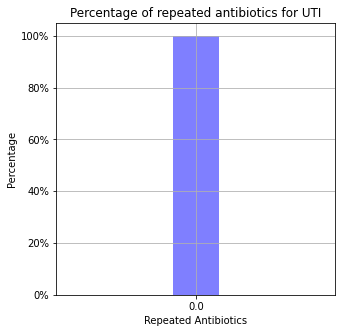

In [126]:
data['repeated_ABs_UTI'].value_counts(np.nan).sort_index().plot(kind='bar', figsize=(5, 5), rot=0, color = 'blue', alpha=0.5, width=0.1)
plt.xlabel('Repeated Antibiotics')
plt.ylabel('Percentage')
plt.title('Percentage of repeated antibiotics for UTI')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.grid()
print(data['repeated_ABs_UTI'].value_counts().sort_index())
plt.savefig(r'../output/hospitalisation_risk/repeated_ABs_UTI.png', edgecolor='none')
plt.show()

## Questions:
- I expect all dates to be within the one month period that the input data is supposedly generated/collected. How it is justified to have a date of 2020 (e.g. UTI diagnosis), while the data belongs to 2019? Is it becuase of having dummy data?
- Is our focus on repeated ABs for just one specific infection or any repeated ABs for any infection (LRTI and UTI)?